# 2: Regressor

We train an approximation of the log-likelihood function for the points near its maximum.

In [1]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import sklearn.metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import json
import supertree
import tl2cgen
import treelite.frontend
import wrap_c_lib
import os

from alpaca_chi2 import chi2

_optuna = False

## Data loading and preparation

In [2]:
df = pd.read_csv('sample_tutorial.csv')
df.describe()

,log_fa,cqL33/fa,cuR/fa,cdR/fa,clL33/fa,ceR/fa,chi2
count,41638.000000,4.163800e+04,4.163800e+04,4.163800e+04,4.163800e+04,4.163800e+04,41638.000000
mean,6.710931,1.674944e-09,5.206095e-08,7.582442e-08,-1.008463e-07,-1.244107e-08,38.311924
std,0.342768,1.248665e-07,6.214913e-07,6.077427e-07,6.573264e-07,1.339599e-07,29.898190
min,5.995225,-6.841106e-07,-2.875298e-06,-2.889838e-06,-2.939651e-06,-1.981324e-06,12.764648
25%,6.495291,-1.040439e-07,-2.229680e-07,-1.844678e-07,-2.930539e-07,-5.537717e-08,15.528566
50%,6.801755,5.276245e-11,5.222429e-09,9.657293e-08,-5.336264e-08,2.817573e-09,17.654180
75%,6.959833,1.082072e-07,2.491484e-07,2.911214e-07,1.640868e-07,4.984933e-08,80.000000
max,7.518143,9.577512e-07,2.991289e-06,2.873215e-06,2.913317e-06,8.945756e-07,80.000000


Make sure to use same cut-off as the classifier!

In [3]:
cutoff = 10.0

In [4]:
df = df[df['chi2'] < np.min(df['chi2']) + cutoff]

X = df[['log_fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa']]
y = df['chi2']

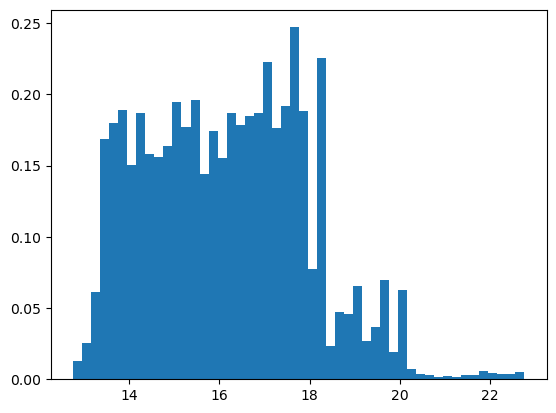

In [5]:
_ = plt.hist(y, bins=50, density=True)

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

dtrain = xgb.DMatrix(X_train.values.astype(np.float32), label=y_train.values.astype(np.float32))
dval = xgb.DMatrix(X_val.values.astype(np.float32), label=y_val.values.astype(np.float32))

## Example of training

In [7]:
params = {
    'objective': 'reg:squarederror', # Regression with squared error
    'tree_method': 'hist', # Faster tree construction algorithm
    'max_depth': 6, # Maximum depth of the tree
    'learning_rate': 0.1, # Step size shrinkage
    'gamma': 0, # Minimum loss reduction required to make a further partition
    'min_child_weight': 1, # Minimum sum of instance weight needed in a child
    'subsample': 0.8, # Fraction of samples to use for each tree
    'colsample_bytree': 0.8, # Fraction of features to use for each tree
    'eval_metric': 'mae', # Evaluation metric
    'nthread': -1, # Use all available CPU cores
}

evals = [(dtrain, 'train'), (dval, 'eval')]

model_regr = xgb.train(params, dtrain, num_boost_round=5000, evals=evals, early_stopping_rounds=5, verbose_eval=False)

In [8]:
model_regr.predict(xgb.DMatrix([[np.log10(3e7), 1e-8, 1e-8, 1e-8, 1e-8, 1e-8]]))

array([18.227945], dtype=float32)

## Choosing the right hyperparameters (optional)

In [9]:
def optuna_obj(trial):
    params = {
        'objective': 'reg:squarederror', # Regression with squared error
        'tree_method': 'hist', # Faster tree construction algorithm
        'max_depth': trial.suggest_int('max_depth', 2, 6), # Maximum depth of the tree
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3), # Step size shrinkage
        'gamma': trial.suggest_float('gamma', 0, 5), # Minimum loss reduction required to make a further partition
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # Minimum sum of instance weight needed in a child
        'subsample': trial.suggest_float('subsample', 0.5, 1.0), # Fraction of samples to use for each tree
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0), # Fraction of features to use for each tree
        'eval_metric': 'mae', # Evaluation metric
        'nthread': -1, # Use all available CPU cores
        'base_score': trial.suggest_float('base_score', -1.0, 1.0), # Initial prediction score
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1.2),
    }

    model_regr = xgb.train(params, dtrain, num_boost_round=500, evals=evals, early_stopping_rounds=15, verbose_eval=False)
    predictions = model_regr.predict(dval)
    mae = sklearn.metrics.mean_absolute_error(y_val, predictions)
    return mae

In [10]:
if _optuna:

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='minimize')
    study.optimize(optuna_obj, n_trials=800, timeout=120, n_jobs=-1, show_progress_bar=True)

    with open('best_params_reg.json', 'w') as f:
        json.dump(study.best_params, f)

## Training

In [11]:
with open('best_params_reg.json', 'r') as f:
    best_params = json.load(f)

best_params

{'max_depth': 6,
 'learning_rate': 0.299861931633084,
 'gamma': 0.0018055431616229348,
 'min_child_weight': 8,
 'subsample': 0.9833428010601422,
 'colsample_bytree': 0.895517599009379,
 'base_score': -0.5181630275939685,
 'reg_alpha': 0.07869533648836147,
 'reg_lambda': 0.1760662640461039}

In [12]:
eval_results = {}

model_regr = xgb.train(best_params | {'objective': 'reg:squarederror', 'tree_method': 'hist', 'eval_metric': ['mae', 'rmse'], 'nthread': -1}, dtrain, num_boost_round=500, evals=evals, early_stopping_rounds=15, verbose_eval=False, evals_result=eval_results)

In [13]:
eval_results['train']['mae'][-1], eval_results['eval']['mae'][-1]

(0.07383599198451925, 0.14321192620096548)

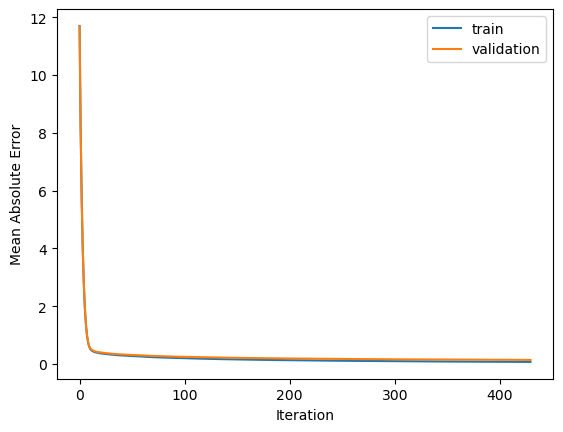

In [14]:
plt.plot(eval_results['train']['mae'], label='train')
plt.plot(eval_results['eval']['mae'], label='validation')
plt.xlabel('Iteration')
plt.ylabel('Mean Absolute Error')
plt.legend()

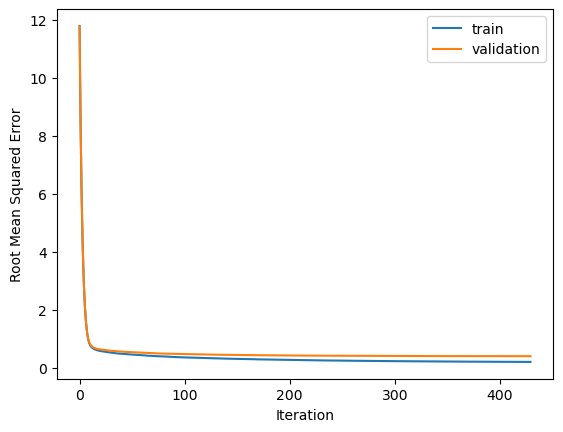

In [15]:
plt.plot(eval_results['train']['rmse'], label='train')
plt.plot(eval_results['eval']['rmse'], label='validation')
plt.xlabel('Iteration')
plt.ylabel('Root Mean Squared Error')
plt.legend()

Here we have a subtle issue: the metrics in the validation dataset keep improving, but very marginally. As long as the metrics are improving, the early stopping doesn't apply, so we keep training and in fact we are overfitting!

Text(0, 0.5, 'Change in MAE (validation)')

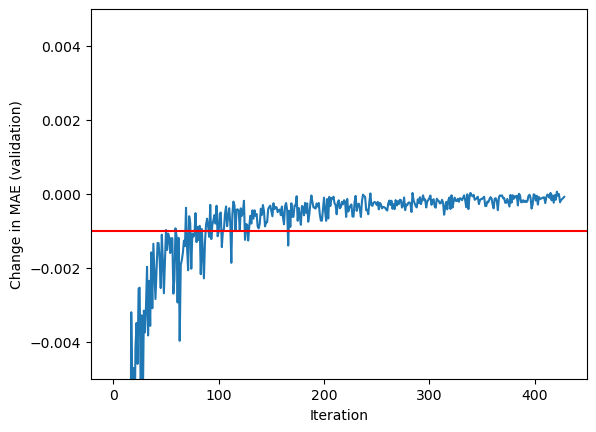

In [16]:
plt.plot(np.diff(eval_results['eval']['mae']))
plt.axhline(-0.001, c='r')
plt.ylim(-0.005, 0.005)
plt.xlabel('Iteration')
plt.ylabel('Change in MAE (validation)')

As a band-aid solution, we'll include our own early stopping criterion: we stop adding trees once the MAE in the validation dataset never improves between consecutive rounds by at least 0.001:

In [17]:
for max_it in range(model_regr.best_iteration):
  improvement = np.min(np.diff(eval_results['eval']['mae'])[max_it:])
  if improvement > -0.001:
    print(max_it)
    break

167


We can use a sub-ensemble of the trained ensemble by just indexing which trees are included:

In [18]:
model_regr_1 = model_regr[0:max_it]

model_regr_1.predict(xgb.DMatrix([[np.log10(3e7), 1e-8, 1e-8, 1e-8, 1e-8, 1e-8]]))

array([20.054592], dtype=float32)

In [19]:
model_regr_1.save_model('xgb_regressor.ubj')

In [20]:
tree_reg = treelite.frontend.from_xgboost(model_regr_1)
tl2cgen.export_lib(tree_reg, toolchain='gcc', libpath='xgb_regressor.so', params={'parallel_comp': 4})

[22:58:34] /Users/runner/miniforge3/conda-bld/tl2cgen_1761589514529/work/src/compiler/ast/split.cc:35: Parallel compilation enabled; member trees will be divided into 4 translation units.


In [21]:
st = supertree.SuperTree(model_regr_1, X.values, y.values, feature_names = list(X.columns))

In [22]:
st.show_tree(4)

## Using the compiled library

In [23]:
nb_root = os.path.abspath(os.getcwd())

xgb_clf = wrap_c_lib.load_c_lib(os.path.join(nb_root, 'xgb_classifier.so'))
xgb_reg = wrap_c_lib.load_c_lib(os.path.join(nb_root, 'xgb_regressor.so'))

In [25]:
x0 = np.array([[ 7.28604262e+00,  1.37740761e-07, -1.40002065e-07,  1.45871549e-07,
        1.45609547e-07,  6.49409347e-08]])
x0 = x0.astype(np.float32, order='C')

x0_df = pd.DataFrame(x0, columns=['fa', 'cqL33/fa', 'cuR/fa', 'cdR/fa', 'clL33/fa', 'ceR/fa'])
dx0 = xgb.DMatrix(x0_df)

In [26]:
%%timeit

xgb_reg(x0)


14.5 μs ± 928 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [27]:
%%timeit

model_regr_1.predict(dx0)

211 μs ± 6.35 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [28]:
def predict(x):
  return np.where(xgb_clf(x) > 0.5, xgb_reg(x), np.inf)

In [29]:
fa = 10**7.26384736e+00
npoints_reg = 200

points = np.vstack([np.full(npoints_reg, 7.26384736e+00), np.linspace(-3, 3, npoints_reg)/fa, np.full(npoints_reg, 2.52262941e-08), np.full(npoints_reg, 1.50785557e-07), np.full(npoints_reg, -3.73326619e-08), np.full(npoints_reg, -6.01368902e-09)]).T

In [30]:
npoints_alpaca = 50

points_phys = np.vstack([np.full(npoints_alpaca, fa), np.linspace(-3, 3, npoints_alpaca), np.full(npoints_alpaca, 2.52262941e-08*fa), np.full(npoints_alpaca, 1.50785557e-07*fa), np.full(npoints_alpaca, -3.73326619e-08*fa), np.full(npoints_alpaca, -6.01368902e-09*fa)]).T

In [31]:
true_chi2 = []

from tqdm import tqdm

for p in tqdm(points_phys):
  true_chi2.append(chi2(*p))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [03:30<00:00,  4.22s/it]


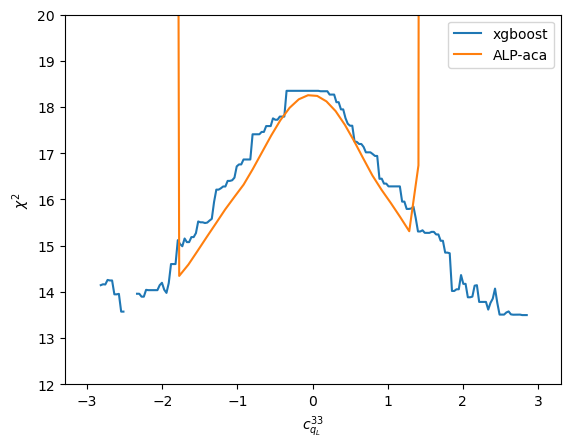

In [32]:
plt.plot(np.linspace(-3, 3, npoints_reg), predict(points), label='xgboost')
plt.plot(np.linspace(-3, 3, npoints_alpaca), true_chi2, label='ALP-aca')
plt.xlabel(r'$c_{q_L}^{33}$')
plt.ylabel(r'$\chi^2$')
plt.ylim(12, 20)
plt.legend()